# Згадки про персонажів

In [1]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Видобування та таблиця

In [2]:
INPUT_FILE = "../lab01/Zabrodin_file_2.json"
OUTPUT_FILE = "Zabrodin_characters_full.csv"


def extract_names(file_path):
    candidates = []

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    result = data.get("result", "")

    for line in result.splitlines():
        if not line or line.startswith("#"):
            continue

        fields = line.split("\t")
        if len(fields) < 10:
            continue

        lemma = fields[2]
        pos_tag = fields[3]
        feats = fields[5]

        if pos_tag == "PROPN":
            if "NameType=Giv" in feats or "NameType=Sur" in feats:
                candidates.append(lemma.strip().title())

    return candidates


names_list = extract_names(INPUT_FILE)
character_counts = Counter(names_list)
top_characters = character_counts.most_common()

df = pd.DataFrame(top_characters, columns=["Персонаж", "Частота"])
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

display(df)

,Персонаж,Частота
0,Мотря,431
1,Лаврін,327
2,Кайдашиха,316
3,Карпо,280
4,Кайдаш,253
...,...,...
118,Меланка,1
119,Василь,1
120,Груша,1
121,Груш,1


Отримано список імен. Серед них є однакові імена, але у різних відмінках або імена з помилкою у написані, через що вони були розпізнані як різні. Також у списку є і не імена зовсім. Проте імена головних героїв та деяких другорядних були розпізнані.

### Фільтрація результатів

Емпіричним шляхом було встановлено частотний поріг (>9 згадувань), що дозволило відфільтрувати більшість неправильно розпізнаних імен. Однак навіть після цього у списку залишилися недійсні значення.

In [3]:
threshold = 9
df_filtered = df[df["Частота"] >= threshold]
display(df_filtered)

,Персонаж,Частота
0,Мотря,431
1,Лаврін,327
2,Кайдашиха,316
3,Карпо,280
4,Кайдаш,253
5,Мелашка,163
6,Палажка,44
7,Параска,19
8,Балаш,16
9,Карпе,14


Навіть після цього у список імен потрапили недійсні значення. Неправильна лема "Карпе" та фонове ім'я "Миколай", вилучимо самостійно.

In [4]:
OUTPUT_FILE = "Zabrodin_characters_filtered.csv"

names_to_remove = ["Карпе", "Миколай"]
df_filtered = df_filtered[~df_filtered["Персонаж"].isin(names_to_remove)]

df_filtered.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

display(df_filtered)

,Персонаж,Частота
0,Мотря,431
1,Лаврін,327
2,Кайдашиха,316
3,Карпо,280
4,Кайдаш,253
5,Мелашка,163
6,Палажка,44
7,Параска,19
8,Балаш,16
10,Балашиха,12


## Дослідження

Для дослідження імен оберемо очищений файл "Zabrodin_characters_filtered.csv" з 12 іменами.

In [5]:
characters = df_filtered["Персонаж"].tolist()

VOWELS = set("аеєиіїоуюя")
SOFT_SIGN = set("ьʼ'")
SOFTENERS = set("ьіяює")
SONORANTS = set("вйлмнр")
VOICELESS = set("кптфхцчшщс")
VOICED = set("бгґджз")


def get_phonetic_profile(name):
    name_lower = name.lower()

    vowels = [c for c in name_lower if c in VOWELS]
    consonants = [c for c in name_lower if c.isalpha() and c not in VOWELS and c not in SOFT_SIGN]

    consonants_count = len(consonants)
    vowels_count = len(vowels)

    sonorants_c = sum(1 for c in consonants if c in SONORANTS)
    voiceless_c = sum(1 for c in consonants if c in VOICELESS)
    voiced_c = sum(1 for c in consonants if c in VOICED)

    soft_c = 0
    hard_c = 0

    for i, char in enumerate(name_lower):
        if char.isalpha() and char not in VOWELS and char not in SOFT_SIGN:
            if char == 'й':
                soft_c += 1
            elif i + 1 < len(name_lower) and name_lower[i + 1] in SOFTENERS:
                soft_c += 1
            else:
                hard_c += 1

    melody_index = round(sonorants_c / consonants_count, 2) if consonants_count else 0
    harshness_index = round(voiceless_c / consonants_count, 2) if consonants_count else 0
    vc_ratio = round(vowels_count / consonants_count, 2) if consonants_count else 0

    return {
        "Персонаж": name,
        "Довжина": len(name_lower),
        "Голосні (V)": vowels_count,
        "Приголосні (C)": consonants_count,
        "З них дзвінкі": voiced_c,
        "З них глухі": voiceless_c,
        "З них сонорні": sonorants_c,
        "З них тверді": hard_c,
        "З них м'які": soft_c,
        "V/C Відношення": vc_ratio,
        "Частка сонорних": melody_index,
        "Частка глухих": harshness_index,
    }


df_phonetics = pd.DataFrame([get_phonetic_profile(n) for n in characters])

df_phonetics.to_csv("Zabrodin_characters_analysis.csv", index=False, encoding="utf-8")
display(df_phonetics)

,Персонаж,Довжина,Голосні (V),Приголосні (C),З них дзвінкі,З них глухі,З них сонорні,З них тверді,З них м'які,V/C Відношення,Частка сонорних,Частка глухих
0,Мотря,5,2,3,0,1,2,2,1,0.67,0.67,0.33
1,Лаврін,6,2,4,0,0,4,3,1,0.50,1.00,0.00
2,Кайдашиха,9,4,5,1,3,1,4,1,0.80,0.20,0.60
3,Карпо,5,2,3,0,2,1,3,0,0.67,0.33,0.67
4,Кайдаш,6,2,4,1,2,1,3,1,0.50,0.25,0.50
5,Мелашка,7,3,4,0,2,2,4,0,0.75,0.50,0.50
6,Палажка,7,3,4,1,2,1,4,0,0.75,0.25,0.50
7,Параска,7,3,4,0,3,1,4,0,0.75,0.25,0.75
8,Балаш,5,2,3,1,1,1,3,0,0.67,0.33,0.33
9,Балашиха,8,4,4,1,2,1,4,0,1.00,0.25,0.50


## Гіпотези та їх доведення

Створимо словник із сексуальними статтями визначених героїв твору

In [6]:
gender_map = {
    'Мотря': 'Ж',
    'Лаврін': 'Ч',
    'Кайдашиха': 'Ж',
    'Карпо': 'Ч',
    'Кайдаш': 'Ч',
    'Мелашка': 'Ж',
    'Палажка': 'Ж',
    'Параска': 'Ж',
    'Балаш': 'Ч',
    'Балашиха': 'Ж',
    'Берко': 'Ч',
    'Довбиш': 'Ч',
}

In [7]:
INPUT_FILE = "Zabrodin_characters_analysis.csv"

### V/C відношення

У цій характеристиці прослідковується така закономірність: шість імен (рівно половина отриманих) з найбільшим значенням є іменами жінок у цьому творі. Натомість найменші значення мають чоловіки.

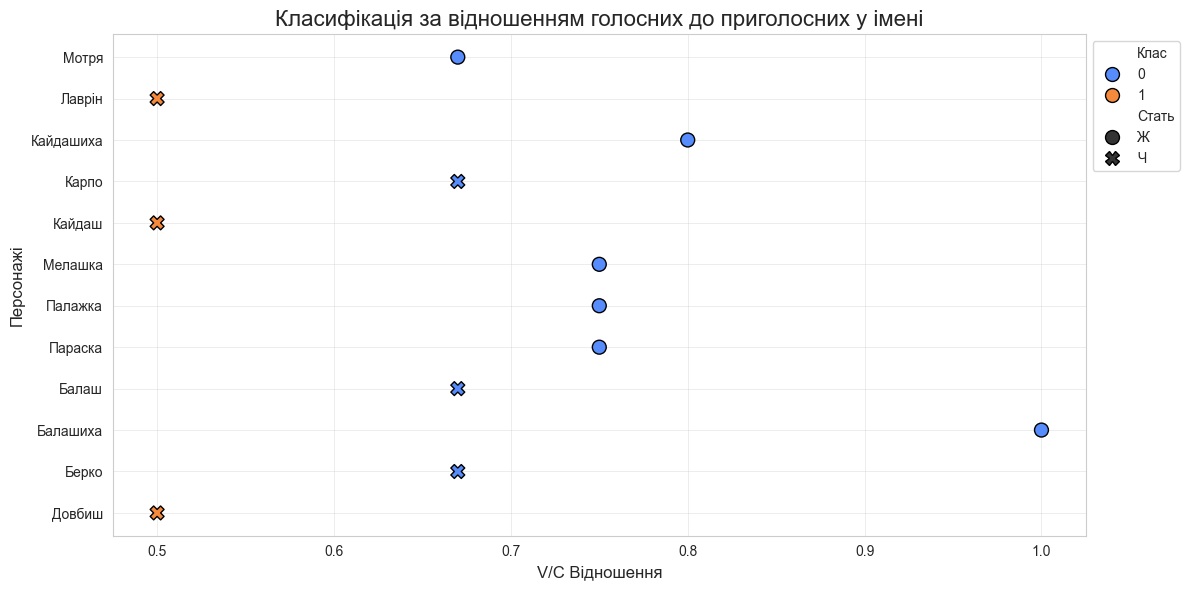

In [8]:
OUTPUT_IMAGE = "Zabrodin_VC_ratio.png"

df_vc_ratio = pd.read_csv(INPUT_FILE)
df_vc_ratio['Стать'] = df_vc_ratio['Персонаж'].map(gender_map)

features = ['V/C Відношення']
X = df_vc_ratio[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_vc_ratio['Клас'] = kmeans.fit_predict(X_scaled)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_vc_ratio,
    x='V/C Відношення',
    y='Персонаж',
    hue='Клас',
    style='Стать',
    s=100,
    edgecolor='black',
    linewidth=1,
    ax=ax
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set_title("Класифікація за відношенням голосних до приголосних у імені", fontsize=16)
ax.set_xlabel("V/C Відношення", fontsize=12)
ax.set_ylabel("Персонажі", fontsize=12)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format='png', transparent=True, dpi=300)

plt.show()

In [9]:
df_vc_ratio['Стать_Число'] = df_vc_ratio['Стать'].map({'Ч': 0, 'Ж': 1})
correlation, p_value = spearmanr(df_vc_ratio['V/C Відношення'], df_vc_ratio['Стать_Число'])

print("Spearman")
print(f"Коефіцієнт кореляції: {correlation:.3f}")
print(f"p-value: {p_value:.3f}")

Spearman
Коефіцієнт кореляції: 0.823
p-value: 0.001


За графіком бачимо, що наше спостереження дійсно справдилося, але окрім імен жінок твору, до того ж класу віднеслися значення деяких чоловіків. Це сталося через однакове значення відношення голосних до приголосних в іменах персонажів твору.

### Частка сонорних

У цій характеристиці можна побачити, що в імені Лаврін усі приголосні є сонорними. Тобто ім'я є мелодичним та м'яким, цю ж особливість можна побачити у характері цього персонажу. Крім цього двома іншими іменами з найбільшою часткою сонорних приголосних є Мотря та Мелашка: дві молоді головні героїні, яким не дивлячись на свою жіночність на початку твору, довелось стати на свій захист будь-то словесно чи вже фізично.

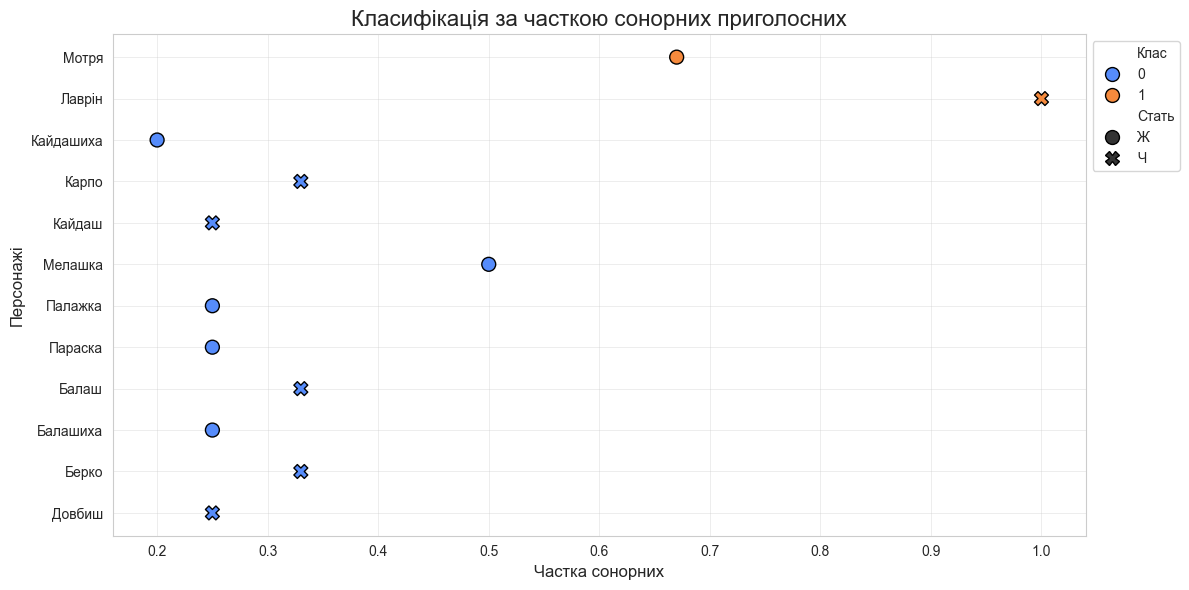

In [10]:
OUTPUT_IMAGE = "Zabrodin_sonorous_ratio.png"

df_sonorous = pd.read_csv(INPUT_FILE)
df_sonorous['Стать'] = df_sonorous['Персонаж'].map(gender_map)

features = ['Частка сонорних']
X = df_sonorous[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_sonorous['Клас'] = kmeans.fit_predict(X_scaled)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_sonorous,
    x='Частка сонорних',
    y='Персонаж',
    hue='Клас',
    style="Стать",
    s=100,
    edgecolor='black',
    linewidth=1,
    ax=ax
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set_title("Класифікація за часткою сонорних приголосних", fontsize=16)
ax.set_xlabel("Частка сонорних", fontsize=12)
ax.set_ylabel("Персонажі", fontsize=12)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format='png', transparent=True, dpi=300)

plt.show()

Ця гіпотеза теж частково підтверджена. Імена Лаврін та Мотря віднесено до іншого класу, проте до нього не увійшло ім'я Мелашка.

### Частка глухих

Тут проглядається така закономірність: два головні герої Кайдаш та Кайдашиха мають одні з найбільших значень, вони є старими, але сильними героями, у можливостях яких зазвичай не сумніваються, їх поважають. На противагу м'якості імені Лавріна, Карпо має більше значення частки глухих, це можна пов'язати з тим, що він є старшим братом.

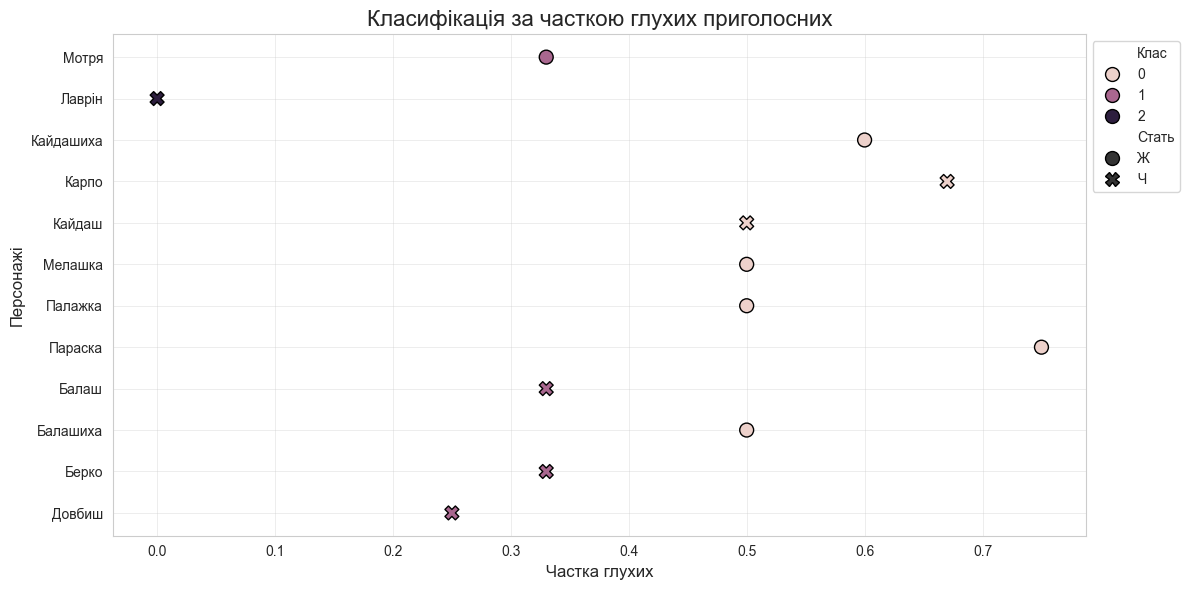

In [12]:
OUTPUT_IMAGE = "Zabrodin_voiceless_ratio.png"

df_voiceless = pd.read_csv(INPUT_FILE)
df_voiceless['Стать'] = df_voiceless['Персонаж'].map(gender_map)

features = ['Частка глухих']
X = df_voiceless[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_voiceless['Клас'] = kmeans.fit_predict(X_scaled)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_voiceless,
    x='Частка глухих',
    y='Персонаж',
    hue='Клас',
    style="Стать",
    s=100,
    edgecolor='black',
    linewidth=1,
    ax=ax
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set_title("Класифікація за часткою глухих приголосних", fontsize=16)
ax.set_xlabel("Частка глухих", fontsize=12)
ax.set_ylabel("Персонажі", fontsize=12)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format='png', transparent=True, dpi=300)

plt.show()

За цим графіком можна сказати, що наше спостереження лише частково правильне, зокрема протилежність Лавріна до Карпа. Натомість можна вивести нове: всі жінки твору визначені в один єдиний клас за часткою глухих приголосних, але також до них віднесено Карпа та Омелька Кайдашів.

### Схожість характерів персонажів із їх фонетичними ознаками

Окремим випадком можна прослідити майже однаковість характеристик імен Палажка та Параска. Вони є два другорядними героїнями твору, що вже у літах. Вони у багатому чому є схожими: пліткують, брешуть, намагаються вилікувати старого Кайдаша від пияцтва та обидві намагаються завоювати повагу до себе у селі.

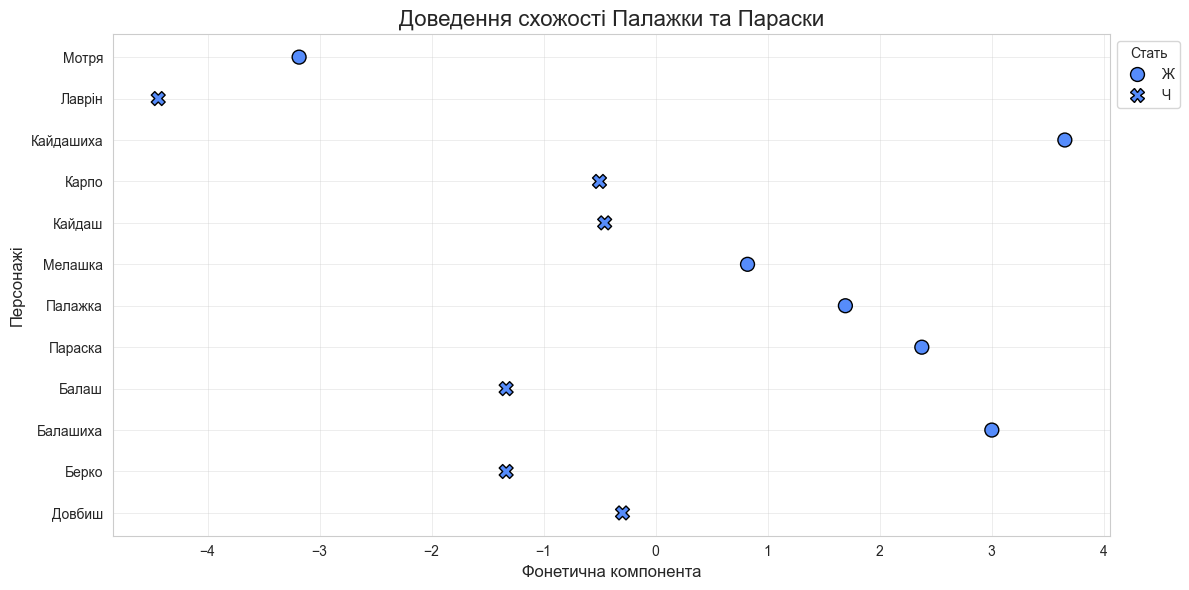

In [13]:
OUTPUT_IMAGE = "Zabrodin_similarity.png"

df_similarity = pd.read_csv(INPUT_FILE)
df_similarity['Стать'] = df_similarity['Персонаж'].map(gender_map)

features = [col for col in df_similarity.columns if col not in ['Персонаж', 'Стать']]
X = df_similarity[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
df_similarity['Схожість'] = pca.fit_transform(X_scaled)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_similarity,
    x='Схожість',
    y='Персонаж',
    style='Стать',
    s=100,
    edgecolor='black',
    linewidth=1,
    ax=ax
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set_title("Доведення схожості Палажки та Параски", fontsize=16)
ax.set_xlabel("Фонетична компонента", fontsize=12)
ax.set_ylabel("Персонажі", fontsize=12)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format='png', transparent=True, dpi=300)

plt.show()

Можна сказати, що гіпотеза підтвердилася. За фонетичними ознаками, зведеними за допомогою PCA до одновимірної осі, чітко видно схожість Параски та Палажки. Проте ще виразніше простежується схожість Карпа та Омелька Кайдашів.

### Аптоніми

* Ім'я старого Кайдаша може бути аптонімом від слова кайдани, оскільки цього героя можна схарактеризувати як одне з джерел проблем у родині Кайдашів, через своє пияцтво він не здатен утримати мир у родині. Таким чином Кайдашиха, завдяки суфіксу '_-иха_' якоюсь мірою додає ще більше проблем у родину.
* Ім'я Мотря може мати зв'язок зі словом мотати, оскільки її характер мотає нерви всій родині, або молоти, бо вона 'молотить язиком'.
* Лаврін може бути пов'язаний зі словом лаври, він є людяним, стійким до інтриг, зберігає моральні цінності попри проблеми у родині.
* Ім'я Берко, власник шинків у Семигорах єврейського походження, схоже на слово брати, що можна віднести до стереотипного мислення автора, коли він писав цей твір.

### Суфікси

Суфікс _-ка_ в імені Мелашки надає йому відтінку зменшеності та пестливості, що відповідає її статусу наймолодшої невістки в родині. Проте варто зазначити, що, крім Мелашки, цей суфікс мають ще Балаш та Палажка.